In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from pandas.tseries.offsets import MonthEnd

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
df = pd.read_csv("BrentOilPrices.csv")

print("Dataset Shape:", df.shape)
print()

print("Column Names:", df.columns)
print()

print("First 5 Rows:")
display(df.head())
print()

print("Data Types:")
print(df.dtypes)
print()

print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (9011, 2)

Column Names: Index(['Date', 'Price'], dtype='object')

First 5 Rows:


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63



Data Types:
Date      object
Price    float64
dtype: object

Missing Values:
Date     0
Price    0
dtype: int64


Dataset seems ot be already clean as there is no missing and duplicate values/records. Also shows that there are only 2 columns one being DATE (object type most likely needs to be converted to datetime and set as the index) and the other being the PRICE on said date (price is float ($) and will most likely remain as float until further notice). 

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.set_index('Date')

display(df.head())

print(df.index)

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


DatetimeIndex(['1987-05-20', '1987-05-21', '1987-05-22', '1987-05-25',
               '1987-05-26', '1987-05-27', '1987-05-28', '1987-05-29',
               '1987-06-01', '1987-06-02',
               ...
               '2022-11-01', '2022-11-02', '2022-11-03', '2022-11-04',
               '2022-11-07', '2022-11-08', '2022-11-09', '2022-11-10',
               '2022-11-11', '2022-11-14'],
              dtype='datetime64[ns]', name='Date', length=9011, freq=None)


As expected date column was converted to datetime type and we chose the date column as index, this is essential and standard practice for the time series analysis that we will perform.

In [5]:
print("Detected Frequency:")
print(pd.infer_freq(df.index))

Detected Frequency:
None


In [6]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

missing_dates = full_range.difference(df.index)

print("Missing Dates Count:")
print(len(missing_dates))

print("\nFirst 10 Missing Dates:")
print(missing_dates[:10])

Missing Dates Count:
3952

First 10 Missing Dates:
DatetimeIndex(['1987-05-23', '1987-05-24', '1987-05-30', '1987-05-31',
               '1987-06-06', '1987-06-07', '1987-06-13', '1987-06-14',
               '1987-06-15', '1987-06-20'],
              dtype='datetime64[ns]', freq=None)


Here we are seeing if the dataset is skipping days. We want to see what the original pattern or frequency of the dates captured is, this will make things clearer for us and help us in making a monthly forecast. Judging by the None detected frequency that tells us that there are skipped dates and that there is no fixed or strict frequency.

In [7]:
monthly_df = df.resample('M').mean()

display(monthly_df.head())

print("Monthly Dataset Shape:")
print(monthly_df.shape)

,Price
Date,
1987-05-31,18.580000
1987-06-30,18.860476
1987-07-31,19.856522
1987-08-31,18.979524
1987-09-30,18.313182


Monthly Dataset Shape:
(427, 1)


Since the project calls for monthly forecasting of oil prices, we will give each month its average oil price and set that as the price. Using monthly average will remove daily noise and give a cleaner and more insightful result for the projects objective. Note, rows were reduced down to 427 months.

In [11]:
print("Monthly Shape: ",monthly_df.shape)

print("Missing Values:")
print(monthly_df.isnull().sum())

print("Start Date: ",monthly_df.index.min())

print("End Date: ",monthly_df.index.max())

Monthly Shape:  (427, 1)
Missing Values:
Price    0
dtype: int64
Start Date:  1987-05-31 00:00:00
End Date:  2022-11-30 00:00:00


Performed general validation to make sure data is clean and ready for EDA.

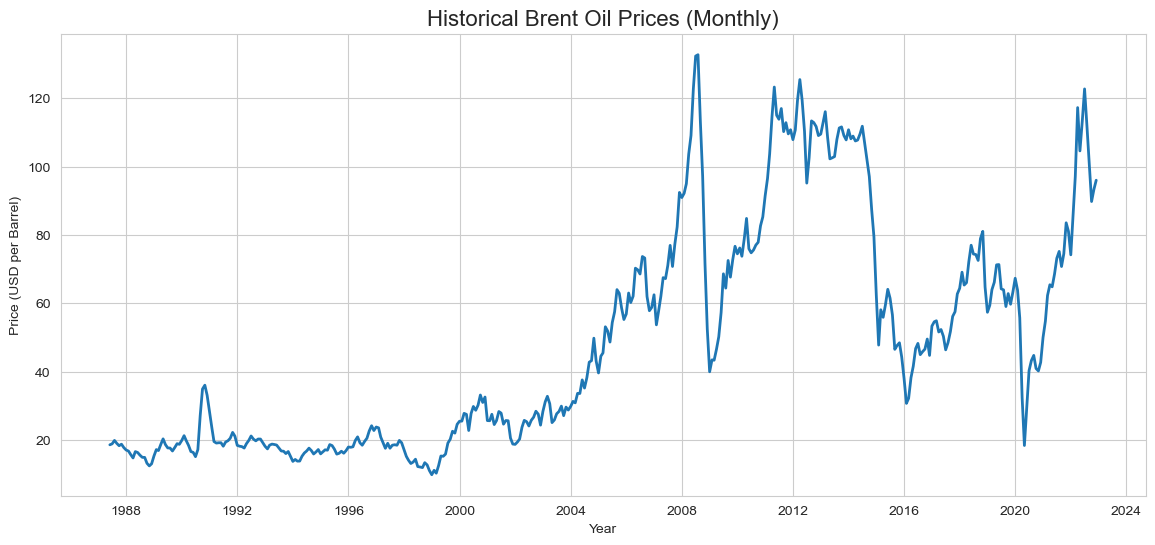

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    linewidth=2
)

plt.title('Historical Brent Oil Prices (Monthly)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')

plt.grid(True)

plt.show()

The figure illustrates the long-term market behavior of oil prices (USD per barrel) from the year 1987 to 2022. We see that the overall general trend is that oil prices have increased overtime indicating increasing global energy demand, with spikes and fluctutations across different years and this leads us to believe that in these specific years, the stability was interrupted my economic disruptions and geopolitical influences.

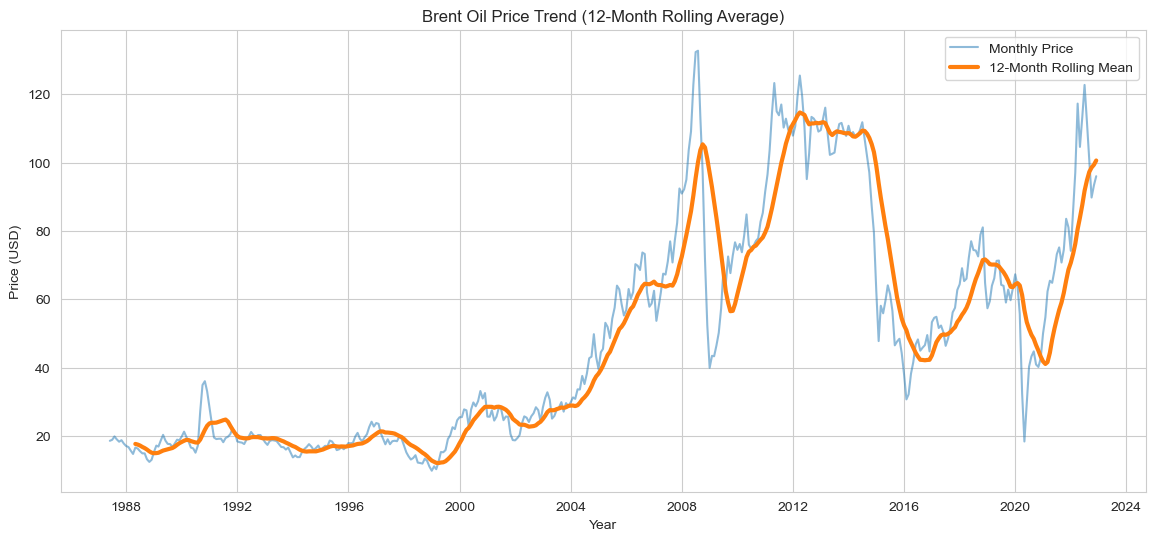

In [13]:
monthly_df['Rolling12'] = (
    monthly_df['Price']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    alpha=0.5,
    label='Monthly Price'
)

plt.plot(
    monthly_df.index,
    monthly_df['Rolling12'],
    linewidth=3,
    label='12-Month Rolling Mean'
)

plt.title('Brent Oil Price Trend (12-Month Rolling Average)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.legend()

plt.grid(True)

plt.show()

This visualization features a 12 month rolling average that smooths out the noise and shows a clearer trend. Our model will also perform better when we have a better understanding of the trend and long-term pattern.

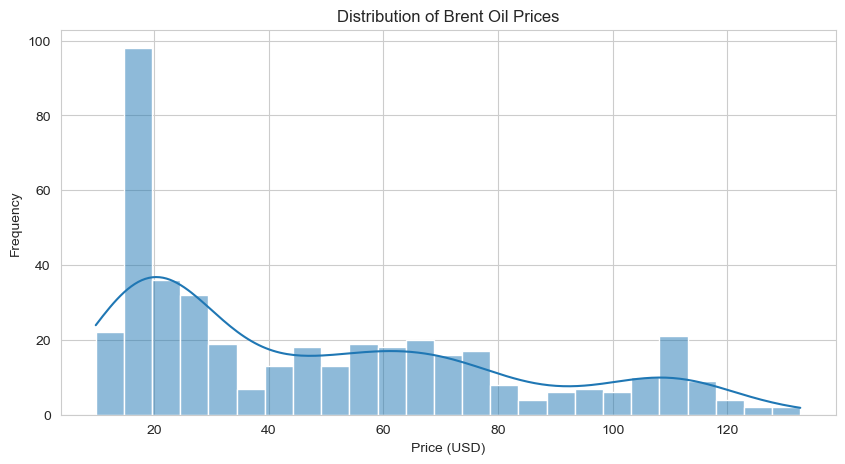

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    monthly_df['Price'],
    bins=25,
    kde=True
)

plt.title('Distribution of Brent Oil Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')

plt.show()

In this distribution plot, we are investigating the distribution of oil prices and as expected its not normally distributed. This helps us identify skewness and outliers, and we clearly see that the distribution is skewed to the right since a higher number of observations is occuring at lower prices and fewer observations at high oil prices.

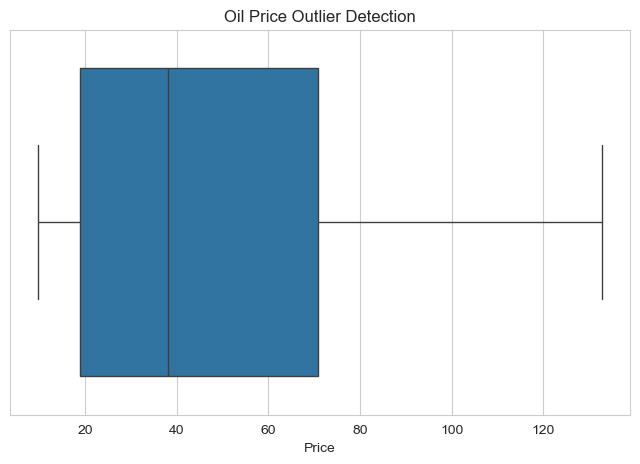

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=monthly_df['Price']
)

plt.title('Oil Price Outlier Detection')

plt.show()

This boxplot shows oil price outliers and provides more descriptive insights.

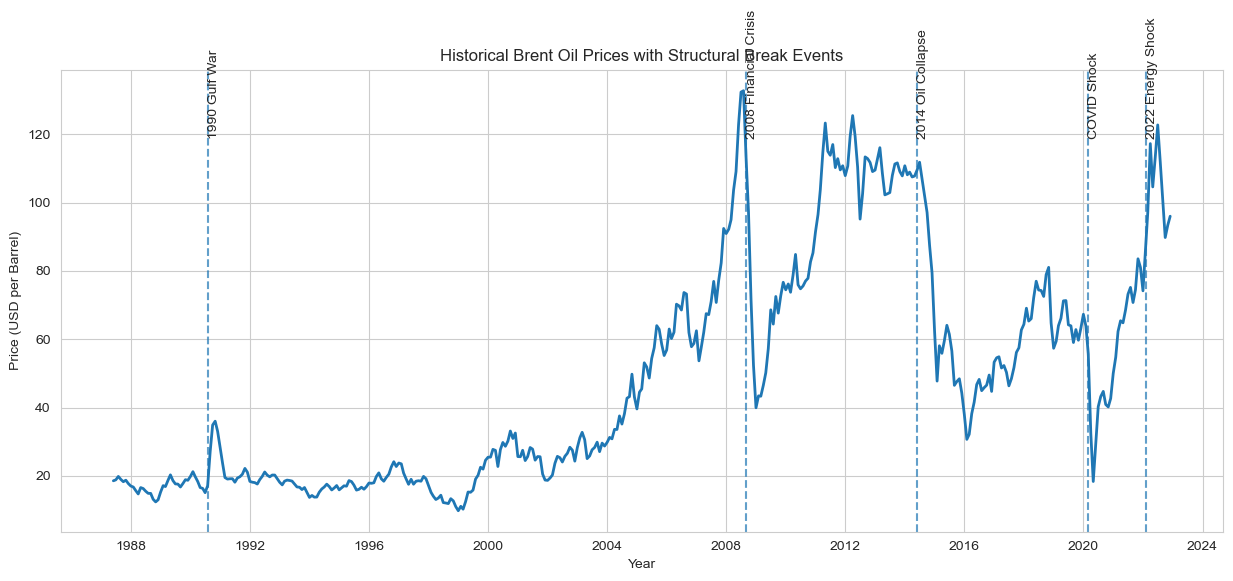

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    linewidth=2
)

events = {
    '1990 Gulf War':'1990-08',
    '2008 Financial Crisis':'2008-09',
    '2014 Oil Collapse':'2014-06',
    'COVID Shock':'2020-03',
    '2022 Energy Shock':'2022-02'
}

for label, date in events.items():

    plt.axvline(
        pd.to_datetime(date),
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        pd.to_datetime(date),
        monthly_df['Price'].max()*0.9,
        label,
        rotation=90
    )

plt.title(
    'Historical Brent Oil Prices with Structural Break Events'
)

plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')

plt.show()

This figure/visualization is very insightful as it illustrates the effects that global economic/historical events had on oil price forecasting and establishes a connection between them.

These events include: The Gulf war (1990), 2008 Financial Crisis, 2014 Oil Collapse, 2020 COVID Shock, and the 2022 Energy Shock.

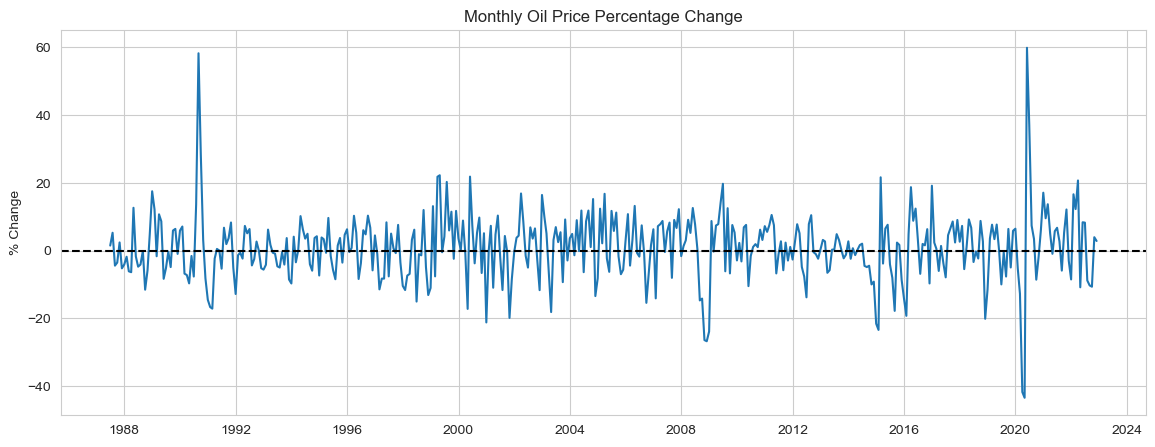

In [19]:
monthly_df['Monthly_Return'] = (
    monthly_df['Price']
    .pct_change()
    *100
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_df.index,
    monthly_df['Monthly_Return']
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title('Monthly Oil Price Percentage Change')

plt.ylabel('% Change')

plt.show()

This figure/visualization measure the volatility by looking at the monthly oil price percentage change. The large spikes indicate instability and structural breaks or disruption in pattern.